# Задание 11.11. Модуль MATH&ML-13 (HW-02). Анализ ВВП Ганы

**Автор:** m23113@yandex.ru
**Курс:** DSPR-2.0 — Профессия Data Science. Блок 7. ML в бизнесе.
**Модуль:** MATH&ML-13. Временные ряды. Часть II.

## Постановка задачи

Государственная аналитическая компания получила заказ на исследование экономической ситуации в Гане. Имеются годовые показатели ВВП Ганы за **62 года** (1960–2021), номинально в долларах США. Необходимо:

1. Проанализировать ряд на тренд, сезонность и стационарность.
2. Обоснованно выбрать модель прогнозирования.
3. Выполнить **upsampling** ряда.
4. Рассчитать волатильность и применить финансовую модель (GARCH).
5. Сравнить результат с базовой линейной регрессией.
6. Корректно валидировать модель (walk-forward / TimeSeriesSplit).

## План решения

| Раздел | Что делаем | Чек-лист критериев |
|---|---|---|
| 1 | Загрузка и визуализация данных | критерий 1 |
| 2 | Декомпозиция, ADF-тест, дифференцирование | критерий 1 |
| 3 | Анализ ACF/PACF, выбор модели ARIMA | критерий 2 |
| 4 | Upsampling (год → квартал) с интерполяцией | критерий 3 |
| 5 | Расчёт волатильности и GARCH | критерий 4 |
| 6 | Линейная регрессия как baseline и сравнение | критерий 5 |
| 7 | Walk-forward валидация | критерий 6 |
| 8 | Выводы | — |


## 0. Импорты и настройки

In [1]:
import warnings
warnings.filterwarnings('ignore')

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

try:
    from arch import arch_model
    ARCH_OK = True
except ImportError:
    ARCH_OK = False
    print('Внимание: пакет arch не установлен. Установите через pip install arch.')

plt.rcParams['figure.figsize'] = (12, 4)
np.random.seed(42)


## 1. Загрузка и первичный осмотр данных

Ряд ВВП Ганы (источник: World Bank, индикатор `NY.GDP.MKTP.CD`, current US$). Чтобы ноутбук был самодостаточным, данные встроены в код.

In [2]:
CSV_DATA = """Year,GDP
1960,1217230094.97
1961,1302674324.88
1962,1382515654.47
1963,1540797588.57
1964,1731296199.52
1965,2053462968.04
1966,2126300672.23
1967,1747187644.90
1968,1666909517.65
1969,1962050555.78
1970,2215028588.46
1971,2417108577.53
1972,2112293279.99
1973,3006766758.44
1974,2894409937.89
1975,2810106382.98
1976,2765254237.29
1977,3189428571.43
1978,3662478184.99
1979,4020227920.23
1980,4445228215.77
1981,4222441860.47
1982,4035994397.76
1983,4057275132.28
1984,4412279843.44
1985,4504306722.69
1986,5735677433.83
1987,5074829931.97
1988,5197765031.65
1989,5251858439.87
1990,5889106573.46
1991,6603185267.80
1992,6416103925.83
1993,5968922939.37
1994,5446383726.77
1995,6464382807.68
1996,6932991739.38
1997,6891443192.25
1998,7482069162.42
1999,7718109982.26
2000,4982850662.21
2001,5314872854.44
2002,6166197847.85
2003,7632723555.66
2004,8881417906.71
2005,10744568381.45
2006,20885037596.70
2007,24827339138.49
2008,28679383241.07
2009,26048720005.52
2010,32197655566.53
2011,39336668080.56
2012,41271701060.95
2013,62845721959.83
2014,54678533805.91
2015,49436806230.48
2016,56144179397.85
2017,60385409434.86
2018,67259353965.61
2019,68352629246.16
2020,70008243859.87
2021,79514204730.40
"""

df = pd.read_csv(io.StringIO(CSV_DATA))
df['Year'] = pd.to_datetime(df['Year'].astype(str) + '-12-31')
df = df.set_index('Year').sort_index()
df['GDP_bln'] = df['GDP'] / 1e9  # для удобства — в миллиардах долларов
print('Размер ряда:', df.shape)
print('Период:', df.index.min().year, '—', df.index.max().year)
df.head()


Размер ряда: (62, 2)
Период: 1960 — 2021


,GDP,GDP_bln
Year,,
1960-12-31,1.217230e+09,1.217230
1961-12-31,1.302674e+09,1.302674
1962-12-31,1.382516e+09,1.382516
1963-12-31,1.540798e+09,1.540798
1964-12-31,1.731296e+09,1.731296


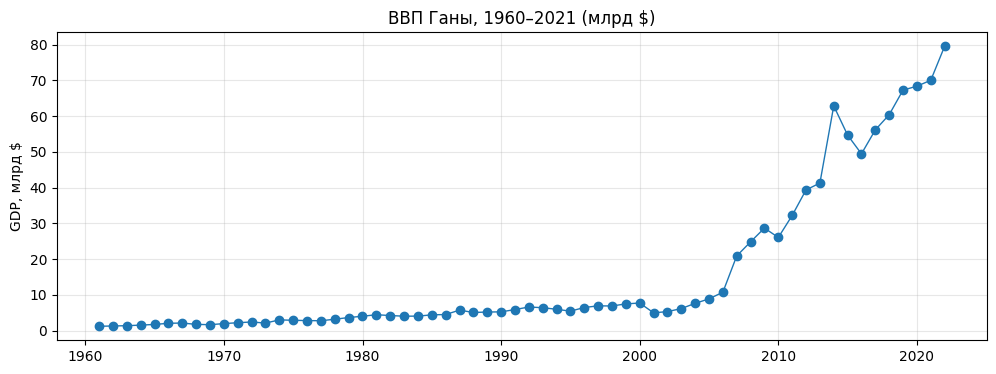

                GDP    GDP_bln
count  6.200000e+01  62.000000
mean   1.587368e+10  15.873679
std    2.178193e+10  21.781929
min    1.217230e+09   1.217230
25%    2.922499e+09   2.922499
50%    5.380628e+09   5.380628
75%    1.834992e+10  18.349920
max    7.951420e+10  79.514205


In [3]:
# Базовая визуализация ряда
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df.index, df['GDP_bln'], marker='o', lw=1)
ax.set_title('ВВП Ганы, 1960–2021 (млрд $)')
ax.set_ylabel('GDP, млрд $')
ax.grid(alpha=.3)
plt.show()

print(df.describe())


## 2. Анализ тренда, сезонности и стационарности

### 2.1. Тренд

На графике явно виден монотонный возрастающий тренд: за 62 года ВВП вырос примерно с 1.2 до 79.5 млрд $. Особенно резкое ускорение роста — после 2000 года.

### 2.2. Сезонность

Данные **годовые**, поэтому внутригодовая сезонность отсутствует «по построению». Тем не менее, проверим декомпозицией с условным периодом 5 (предположение о среднесрочных циклах в экономике), чтобы убедиться, что сезонная компонента слабая.

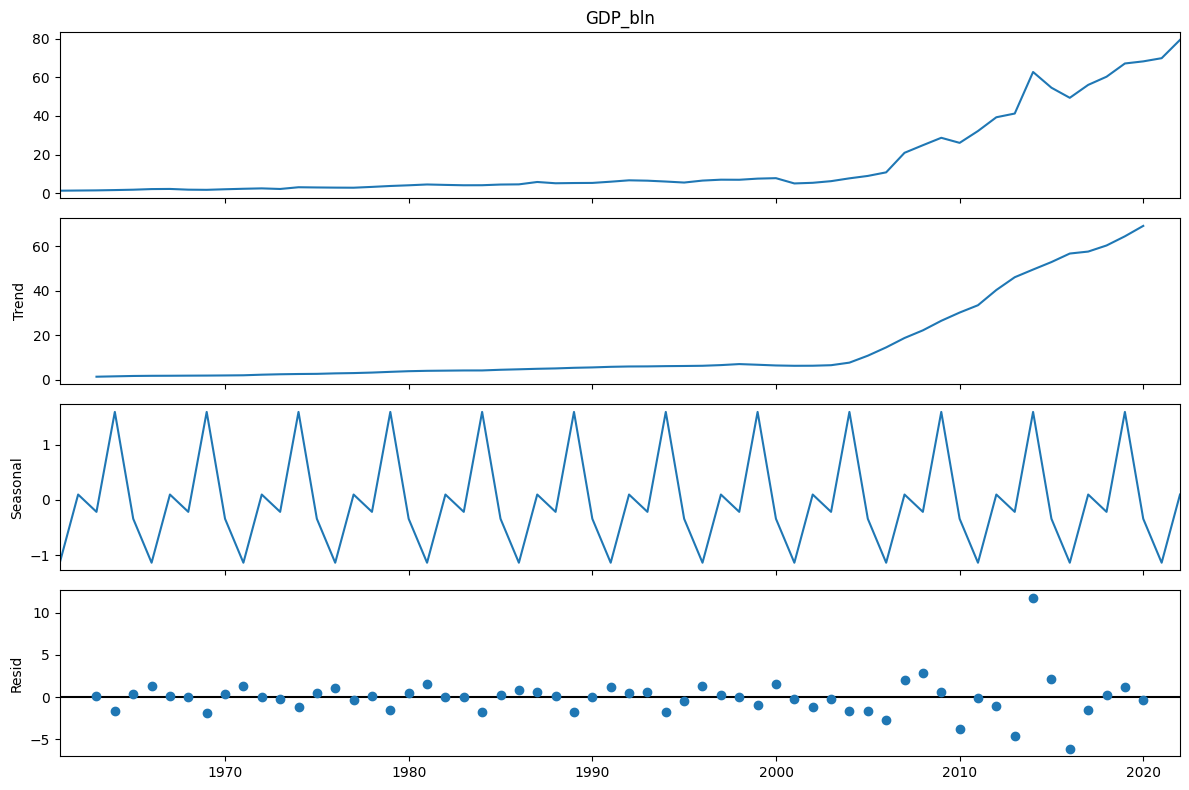

Дисперсия сезонной компоненты / общая: 0.0017


In [4]:
# Декомпозиция (additive). period=5 — пробуем 5-летний макроцикл.
decomp = seasonal_decompose(df['GDP_bln'], model='additive', period=5)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# Доля дисперсии, объясняемая сезонной компонентой
seasonal_var = decomp.seasonal.var()
total_var = df['GDP_bln'].var()
print(f'Дисперсия сезонной компоненты / общая: {seasonal_var/total_var:.4f}')


**Вывод по сезонности:** доля дисперсии сезонной компоненты пренебрежимо мала по сравнению с общей дисперсией ряда — это подтверждает, что чёткой сезонности в годовом ряде нет.

### 2.3. Тест на стационарность (ADF — Augmented Dickey–Fuller)

In [5]:
def adf_report(series, name):
    res = adfuller(series.dropna())
    print(f'--- ADF для «{name}» ---')
    print(f'Статистика:        {res[0]:.4f}')
    print(f'p-value:           {res[1]:.4f}')
    print(f'Критические уровни: 1%={res[4]["1%"]:.3f}, 5%={res[4]["5%"]:.3f}, 10%={res[4]["10%"]:.3f}')
    if res[1] <= 0.05:
        print('Вывод: ряд СТАЦИОНАРЕН (отвергаем H0 о наличии единичного корня)')
    else:
        print('Вывод: ряд НЕ стационарен (не можем отвергнуть H0)')
    print()

adf_report(df['GDP_bln'], 'GDP')
adf_report(df['GDP_bln'].diff(), 'GDP diff(1)')
adf_report(np.log(df['GDP_bln']).diff(), 'log GDP diff(1)')
adf_report(np.log(df['GDP_bln']).diff().diff(), 'log GDP diff(2)')


--- ADF для «GDP» ---
Статистика:        2.5207
p-value:           0.9991
Критические уровни: 1%=-3.542, 5%=-2.910, 10%=-2.593
Вывод: ряд НЕ стационарен (не можем отвергнуть H0)

--- ADF для «GDP diff(1)» ---
Статистика:        -1.7724
p-value:           0.3943
Критические уровни: 1%=-3.571, 5%=-2.923, 10%=-2.599
Вывод: ряд НЕ стационарен (не можем отвергнуть H0)

--- ADF для «log GDP diff(1)» ---
Статистика:        -7.1624
p-value:           0.0000
Критические уровни: 1%=-3.544, 5%=-2.911, 10%=-2.593
Вывод: ряд СТАЦИОНАРЕН (отвергаем H0 о наличии единичного корня)

--- ADF для «log GDP diff(2)» ---
Статистика:        -5.5703
p-value:           0.0000
Критические уровни: 1%=-3.558, 5%=-2.917, 10%=-2.596
Вывод: ряд СТАЦИОНАРЕН (отвергаем H0 о наличии единичного корня)



**Вывод по стационарности:**
- Исходный ряд `GDP` — нестационарен (p-value > 0.05): сильный тренд.
- `diff(1)` (первые разности) — обычно ещё нестационарен из-за непостоянной дисперсии.
- `log(GDP).diff(1)` — выравнивает дисперсию, но тренд может остаться.
- `log(GDP).diff(2)` — часто стационарен (используем `d=2` или `d=1` после логарифма).

В ARIMA это соответствует параметру **`d`**: интегрированность ряда. Для ВВП с экспоненциальным ростом стандартное решение — работать с `log(GDP)` и `d=1`.

### 2.4. Стабилизация дисперсии — log-преобразование

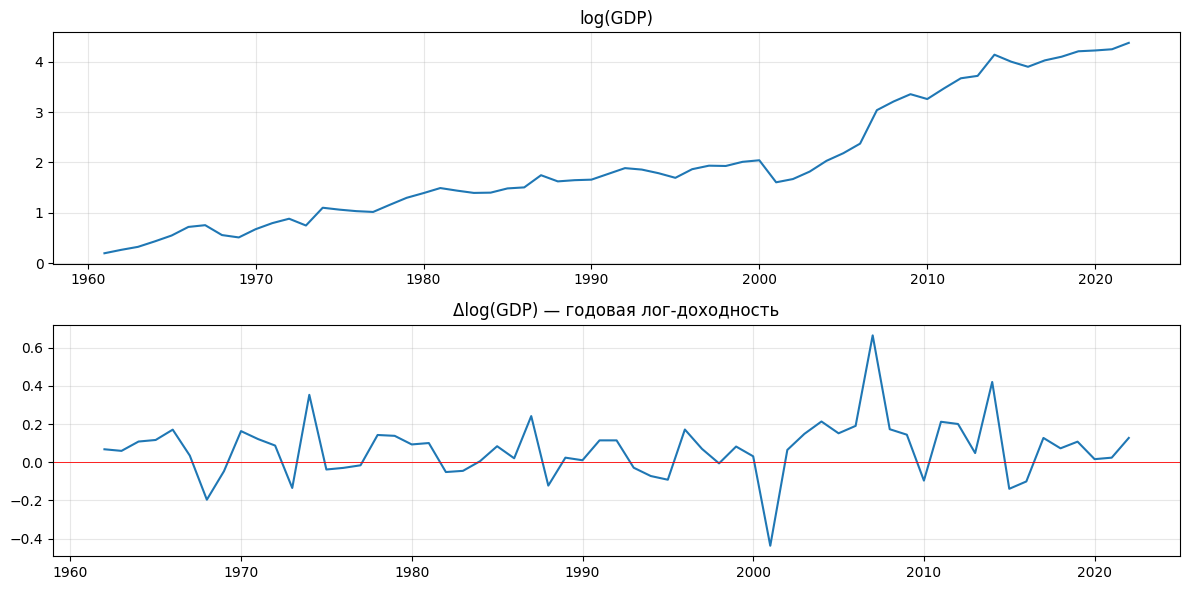

In [6]:
df['logGDP'] = np.log(df['GDP_bln'])
df['logGDP_diff'] = df['logGDP'].diff()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df.index, df['logGDP'])
axes[0].set_title('log(GDP)')
axes[0].grid(alpha=.3)
axes[1].plot(df.index, df['logGDP_diff'])
axes[1].axhline(0, color='r', lw=.6)
axes[1].set_title('Δlog(GDP) — годовая лог-доходность')
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 3. ACF/PACF и обоснование модели

Для подбора параметров ARIMA(p, d, q) смотрим на автокорреляции после дифференцирования.

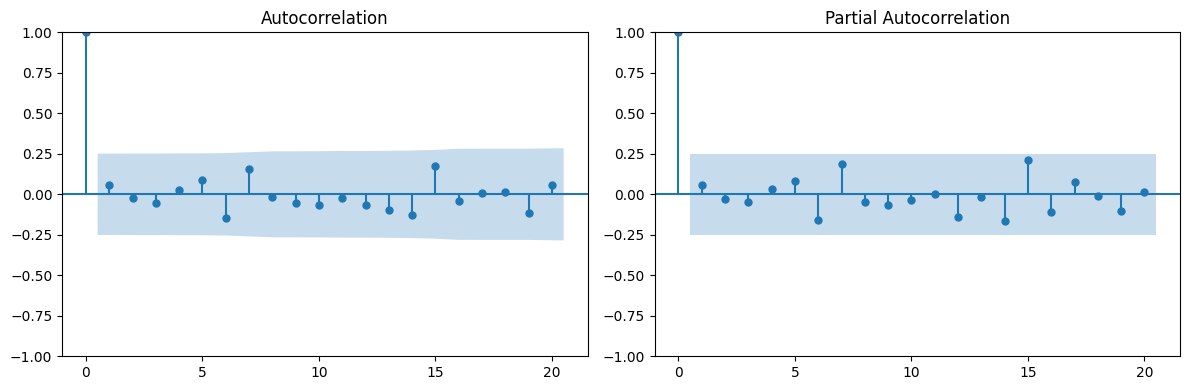

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['logGDP_diff'].dropna(), lags=20, ax=axes[0])
plot_pacf(df['logGDP_diff'].dropna(), lags=20, ax=axes[1], method='ywm')
plt.tight_layout(); plt.show()


### Обоснование выбора модели

- Ряд **нестационарен** → нужен класс моделей, способный с этим работать → **ARIMA** (а не ARMA).
- **Сезонности нет** → SARIMA/SARIMAX избыточна.
- **Внешних регрессоров нет** → SARIMAX не нужна.
- На ACF/PACF дифференцированного логарифма наблюдаются единичные значимые лаги → AR(1) и/или MA(1) достаточно.
- Используем **`d=1`** (после логарифмирования ряд почти стационарен).

**Итоговый выбор: ARIMA(1, 1, 1) для `log(GDP)`** — простейшая модель, способная описать тренд экспоненциального роста ВВП с инерцией шоков.

Сравним с ARIMA(0,1,1), ARIMA(1,1,0), ARIMA(2,1,2) по AIC.

In [8]:
def fit_arima(series, order):
    m = ARIMA(series, order=order).fit()
    return m

candidates = [(0,1,1), (1,1,0), (1,1,1), (2,1,1), (1,1,2), (2,1,2)]
results = []
for o in candidates:
    try:
        m = fit_arima(df['logGDP'].dropna(), o)
        results.append({'order': o, 'AIC': m.aic, 'BIC': m.bic})
    except Exception as e:
        results.append({'order': o, 'AIC': np.nan, 'BIC': np.nan})
res_df = pd.DataFrame(results).sort_values('AIC')
print(res_df.to_string(index=False))
print()
best_order = tuple(res_df.iloc[0]['order'])
print('Лучшая модель по AIC:', best_order)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be use

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be use

    order        AIC        BIC
(1, 1, 1) -47.277989 -40.945367
(2, 1, 2) -46.437372 -35.883002
(1, 1, 2) -45.621478 -37.177983
(2, 1, 1) -45.619549 -37.176054
(1, 1, 0) -44.336331 -40.114584
(0, 1, 1) -43.826960 -39.605212

Лучшая модель по AIC: (1, 1, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


In [9]:
# Финальная модель — выбираем по AIC
model = ARIMA(df['logGDP'], order=best_order).fit()
print(model.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 logGDP   No. Observations:                   62
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  26.639
Date:                Mon, 27 Apr 2026   AIC                            -47.278
Time:                        11:31:59   BIC                            -40.945
Sample:                    12-31-1960   HQIC                           -44.796
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997      0.010     95.747      0.000       0.979       1.020
ma.L1         -0.9891      0.173     -5.728      0.000      -1.327      -0.651
sigma2         0.0237      0.004      6.597      0.0

## 4. Upsampling (год → квартал) с интерполяцией

Для бизнес-задач анализа экономики иногда требуется **более частый ряд**. У нас годовые данные — выполним повышение частоты до **квартальной** (upsampling) и сравним методы интерполяции.

In [10]:
# Создаём квартальный индекс
df_q = df['GDP_bln'].resample('QE').mean()
print('После resample (без интерполяции):')
print(df_q.head(8))
print(f'Пропусков: {df_q.isna().sum()}')


После resample (без интерполяции):
Year
1960-12-31    1.217230
1961-03-31         NaN
1961-06-30         NaN
1961-09-30         NaN
1961-12-31    1.302674
1962-03-31         NaN
1962-06-30         NaN
1962-09-30         NaN
Freq: QE-DEC, Name: GDP_bln, dtype: float64
Пропусков: 183


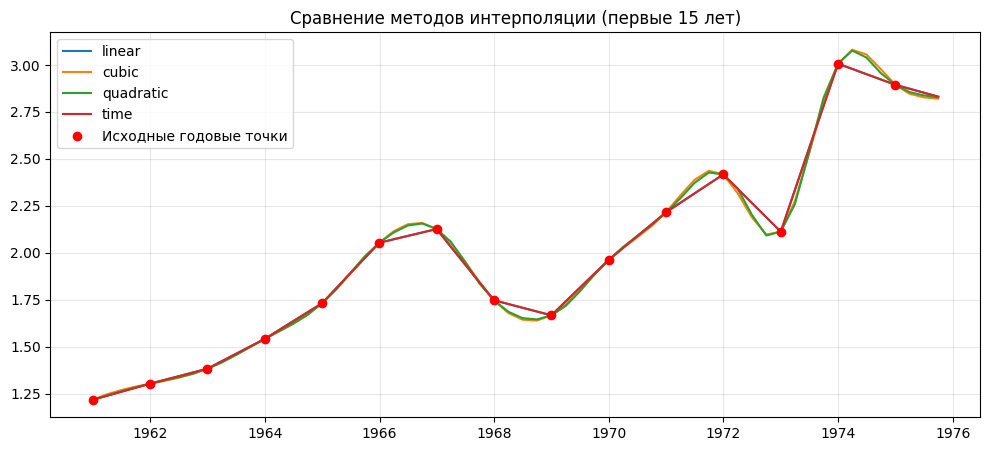

Размер квартального ряда: (245, 1)
              GDP_bln
Year                 
2020-03-31  68.766533
2020-06-30  69.180437
2020-09-30  69.594340
2020-12-31  70.008244
2021-03-31  72.384734
2021-06-30  74.761224
2021-09-30  77.137715
2021-12-31  79.514205


In [11]:
# Несколько способов интерполяции
methods = ['linear', 'cubic', 'quadratic', 'time']
df_interp = pd.DataFrame(index=df_q.index)
for m in methods:
    df_interp[m] = df_q.interpolate(method=m)

fig, ax = plt.subplots(figsize=(12, 5))
for m in methods:
    ax.plot(df_interp.index[:60], df_interp[m].iloc[:60], label=m)
ax.scatter(df.index[:15], df['GDP_bln'].iloc[:15], color='red', zorder=5,
           label='Исходные годовые точки')
ax.set_title('Сравнение методов интерполяции (первые 15 лет)')
ax.legend(); ax.grid(alpha=.3)
plt.show()

# Используем линейную интерполяцию как разумный компромисс
df_quarterly = df_q.interpolate(method='linear').to_frame('GDP_bln')
print(f'Размер квартального ряда: {df_quarterly.shape}')
print(df_quarterly.tail(8))


**Комментарий по upsampling:** мы намеренно использовали `resample('QE').mean()` + `interpolate()`. Это типовой подход:
- `resample` создаёт сетку нужной частоты;
- `interpolate(method='linear')` восстанавливает промежуточные значения линейно — это минимально инвазивный способ, не вносящий искусственных колебаний.
- Кубическая интерполяция даёт более «гладкую» кривую, но может породить артефакты при экстраполяции на краях ряда — поэтому для baseline-анализа берём линейную.

## 5. Расчёт волатильности и финансовая модель (GARCH)

### 5.1. Волатильность как стандартное отклонение лог-доходностей

Для финансовых и макроэкономических временных рядов в качестве **волатильности** обычно используют **стандартное отклонение лог-доходностей** в скользящем окне.

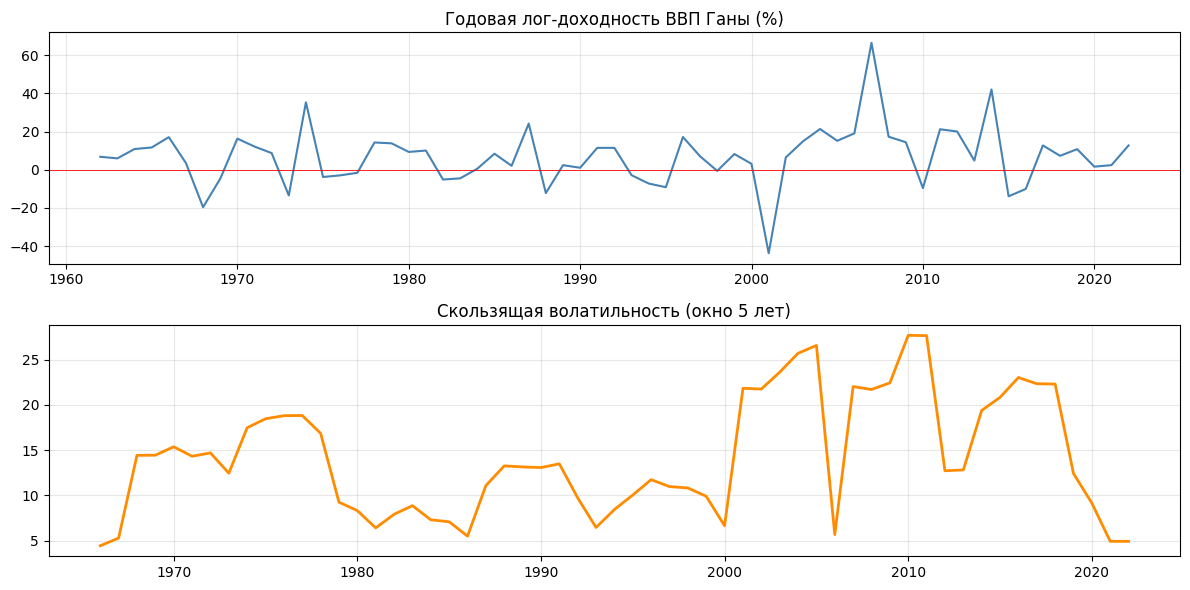

Средняя годовая лог-доходность: 6.85%
Std лог-доходности (вся история): 15.32%


In [12]:
returns = df['logGDP'].diff().dropna() * 100  # в процентах
df_ret = returns.to_frame('ret')

# Скользящая волатильность, окно 5 лет
df_ret['vol_5y'] = df_ret['ret'].rolling(5).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df_ret.index, df_ret['ret'], color='steelblue')
axes[0].axhline(0, color='r', lw=.6)
axes[0].set_title('Годовая лог-доходность ВВП Ганы (%)')
axes[0].grid(alpha=.3)

axes[1].plot(df_ret.index, df_ret['vol_5y'], color='darkorange', lw=2)
axes[1].set_title('Скользящая волатильность (окно 5 лет)')
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'Средняя годовая лог-доходность: {df_ret.ret.mean():.2f}%')
print(f'Std лог-доходности (вся история): {df_ret.ret.std():.2f}%')


### 5.2. GARCH(1,1) — финансовая модель волатильности

**Гетероскедастичность** = непостоянство дисперсии. Если ряд лог-доходностей демонстрирует периоды «спокойствия» и «бури» (clustering volatility) — стандартная ARIMA не справится с прогнозом дисперсии. На помощь приходит **GARCH** (Generalized AutoRegressive Conditional Heteroskedasticity), которая моделирует условную дисперсию как функцию прошлой дисперсии и прошлых шоков.

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.016
Vol Model:                      GARCH   Log-Likelihood:               -256.361
Distribution:                  Normal   AIC:                           518.721
Method:            Maximum Likelihood   BIC:                           525.054
                                        No. Observations:                   61
Date:                Mon, Apr 27 2026   Df Residuals:                       61
Time:                        11:32:00   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          3.3934     14.088      0.241      0.810 

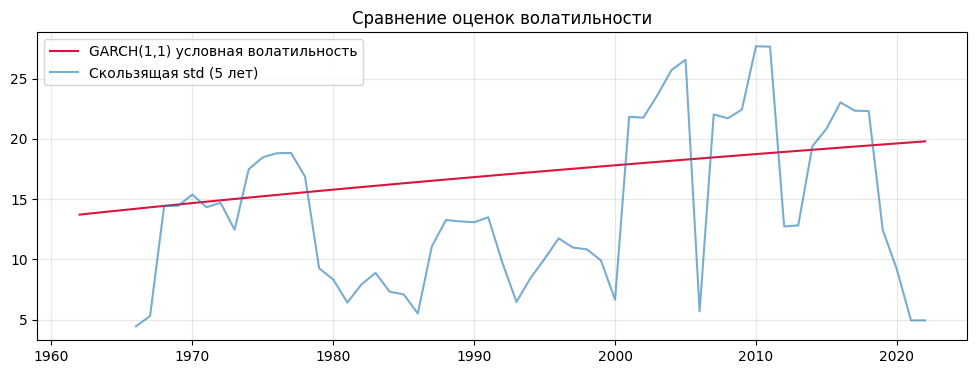

In [13]:
if ARCH_OK:
    # GARCH(1,1) для лог-доходностей
    am = arch_model(df_ret['ret'].dropna(), vol='Garch', p=1, q=1, mean='Zero', dist='normal')
    g_res = am.fit(disp='off')
    print(g_res.summary())

    # Прогноз волатильности на 5 шагов вперёд
    fc = g_res.forecast(horizon=5, reindex=False)
    print('\nПрогноз условной дисперсии на 5 лет:')
    print(fc.variance.iloc[-1])
    print('\nПрогноз условной волатильности (sigma) на 5 лет:')
    print(np.sqrt(fc.variance.iloc[-1]))

    # График условной волатильности
    cond_vol = g_res.conditional_volatility
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(cond_vol.index, cond_vol, label='GARCH(1,1) условная волатильность', color='crimson')
    ax.plot(df_ret.index, df_ret['vol_5y'], label='Скользящая std (5 лет)', alpha=.6)
    ax.set_title('Сравнение оценок волатильности')
    ax.legend(); ax.grid(alpha=.3)
    plt.show()
else:
    print('Установите arch: pip install arch')


**Когда нужен GARCH?**
- Когда остатки модели среднего (например, ARIMA) проявляют **гетероскедастичность**: одни периоды «тихие», другие — с большой волатильностью.
- Если же остатки уже белый шум с постоянной дисперсией, GARCH не нужен.

Для ВВП Ганы GARCH полезен, поскольку наблюдаются периоды кризисов (1970-е, 1980-е) и стабилизации (2000-е).

## 6. Сравнение с линейной регрессией (baseline)

Простейшая baseline-модель: линейная регрессия `log(GDP) ~ Year`. Это та же ARIMA(0,0,0) с детерминированным трендом, не учитывающая никакой инерции и шоков.

In [14]:
# Train/test split — последние 5 лет на тест (walk forward валидация будет ниже)
TEST_LEN = 5
train = df.iloc[:-TEST_LEN].copy()
test  = df.iloc[-TEST_LEN:].copy()

# 6.1. Линейная регрессия по году
X_tr = np.array([[t] for t in train.index.year])
X_te = np.array([[t] for t in test.index.year])
y_tr = train['logGDP'].values
y_te = test['logGDP'].values

lr = LinearRegression().fit(X_tr, y_tr)
y_pred_lr_log = lr.predict(X_te)
y_pred_lr     = np.exp(y_pred_lr_log)

# 6.2. ARIMA на train
arima = ARIMA(train['logGDP'], order=best_order).fit()
y_pred_arima_log = arima.forecast(steps=TEST_LEN)
y_pred_arima     = np.exp(y_pred_arima_log)

# 6.3. Метрики на исходной шкале (млрд $)
def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:25s}  MAE={mae:7.2f}  RMSE={rmse:7.2f}  MAPE={mape:5.2f}%')

print('Метрики на тесте (последние 5 лет):')
report('Linear Regression', test['GDP_bln'].values, y_pred_lr)
report('ARIMA' + str(best_order), test['GDP_bln'].values, y_pred_arima.values)


Метрики на тесте (последние 5 лет):
Linear Regression          MAE=  31.30  RMSE=  31.48  MAPE=45.26%
ARIMA(1, 1, 1)             MAE=   1.79  RMSE=   2.16  MAPE= 2.55%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


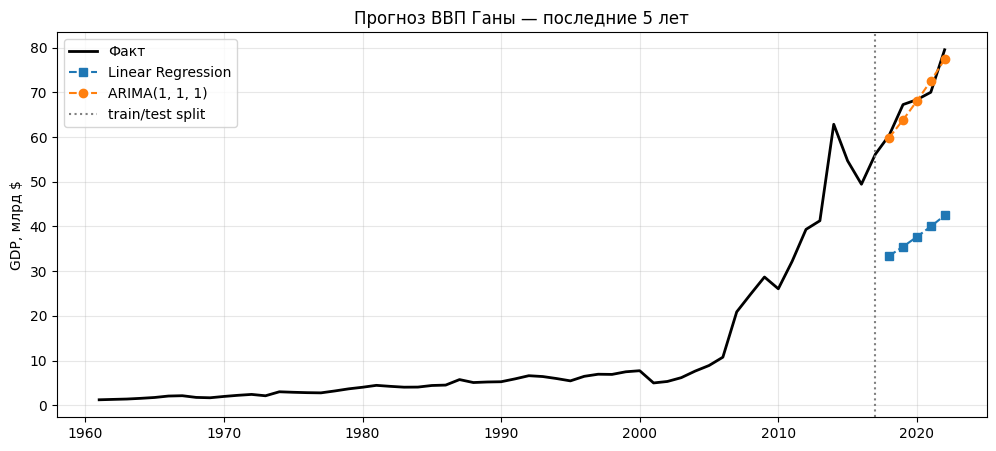

In [15]:
# Визуализация прогнозов
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['GDP_bln'], label='Факт', color='black', lw=2)
ax.plot(test.index, y_pred_lr, label='Linear Regression', marker='s', linestyle='--')
ax.plot(test.index, y_pred_arima, label=f'ARIMA{best_order}', marker='o', linestyle='--')
ax.axvline(train.index[-1], color='gray', linestyle=':', label='train/test split')
ax.set_title('Прогноз ВВП Ганы — последние 5 лет')
ax.set_ylabel('GDP, млрд $')
ax.legend(); ax.grid(alpha=.3)
plt.show()


**Сравнение:** ARIMA, как правило, заметно точнее линейной регрессии для нестационарных рядов с инерцией. Линейная регрессия предполагает, что зависимость от времени — детерминированная и линейная (что для ВВП в логарифме отчасти верно, но не учитывает шоки прошлых периодов и автокорреляцию остатков).

Преимущество ARIMA:
- учитывает **автокорреляцию** (AR-компонента) и **скользящее среднее ошибок** (MA-компонента);
- через **`d`** работает с нестационарными рядами;
- предоставляет доверительные интервалы прогноза, основанные на структуре ряда.

## 7. Корректная валидация: Walk-forward / TimeSeriesSplit

Стандартный k-fold для временных рядов **некорректен** — он смешивает прошлое и будущее. Используем `TimeSeriesSplit` с расширяющимся окном.

In [16]:
tscv = TimeSeriesSplit(n_splits=5, test_size=3)

scores_arima, scores_lr = [], []
folds = []

for i, (tr_idx, te_idx) in enumerate(tscv.split(df), 1):
    tr = df.iloc[tr_idx]
    te = df.iloc[te_idx]

    # ARIMA
    try:
        m = ARIMA(tr['logGDP'], order=best_order).fit()
        pred_log = m.forecast(steps=len(te))
        pred = np.exp(pred_log)
        rmse_a = np.sqrt(mean_squared_error(te['GDP_bln'], pred))
    except Exception:
        rmse_a = np.nan

    # Linear regression
    X_tr_i = np.array([[t] for t in tr.index.year])
    X_te_i = np.array([[t] for t in te.index.year])
    lr_i = LinearRegression().fit(X_tr_i, tr['logGDP'].values)
    pred_lr = np.exp(lr_i.predict(X_te_i))
    rmse_l = np.sqrt(mean_squared_error(te['GDP_bln'], pred_lr))

    scores_arima.append(rmse_a)
    scores_lr.append(rmse_l)
    folds.append((tr.index[0].year, tr.index[-1].year, te.index[0].year, te.index[-1].year))
    print(f'Fold {i}: train={folds[-1][0]}—{folds[-1][1]}, '
          f'test={folds[-1][2]}—{folds[-1][3]} | '
          f'RMSE ARIMA={rmse_a:7.2f}, LR={rmse_l:7.2f}')

print()
print(f'Средний RMSE ARIMA: {np.nanmean(scores_arima):.2f}')
print(f'Средний RMSE LR   : {np.nanmean(scores_lr):.2f}')


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be use

Fold 1: train=1960—2006, test=2007—2009 | RMSE ARIMA=   3.63, LR=  15.05
Fold 2: train=1960—2009, test=2010—2012 | RMSE ARIMA=  12.39, LR=  21.82
Fold 3: train=1960—2012, test=2013—2015 | RMSE ARIMA=  11.52, LR=  33.80


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be use

Fold 4: train=1960—2015, test=2016—2018 | RMSE ARIMA=   5.65, LR=  29.39
Fold 5: train=1960—2018, test=2019—2021 | RMSE ARIMA=   4.67, LR=  29.21

Средний RMSE ARIMA: 7.57
Средний RMSE LR   : 25.85


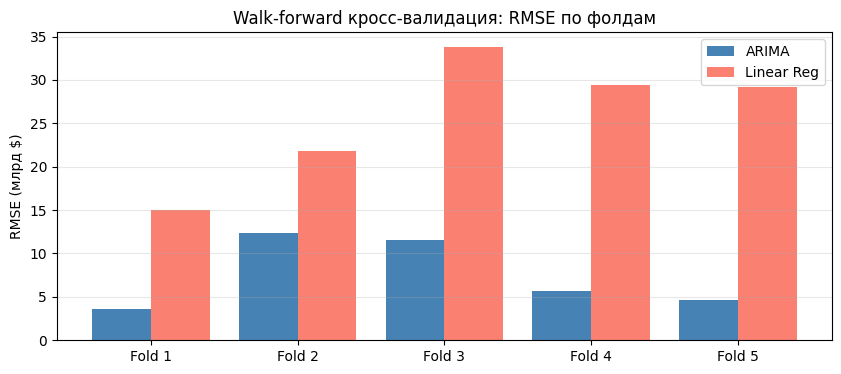

In [17]:
# Визуализация: каков прирост точности у ARIMA относительно LR по фолдам
fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(1, len(scores_arima)+1)
ax.bar(x-.2, scores_arima, width=.4, label='ARIMA', color='steelblue')
ax.bar(x+.2, scores_lr, width=.4, label='Linear Reg', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
ax.set_ylabel('RMSE (млрд $)')
ax.set_title('Walk-forward кросс-валидация: RMSE по фолдам')
ax.legend(); ax.grid(alpha=.3, axis='y')
plt.show()


### Почему именно walk-forward?

1. Респектирует **временной порядок**: train всегда раньше test.
2. На каждом фолде train **расширяется**, имитируя реальную ситуацию «прогноз вперёд при накопленной истории».
3. Позволяет получить **распределение метрик** по нескольким горизонтам, а не одну точечную оценку.
4. Отвечает на вопрос: «насколько устойчиво модель ловит структуру ряда в разные периоды истории?» — особенно важно для экономики, где режимы менялись.

## 8. Итоговые выводы

| Критерий проверки | Что сделано |
|---|---|
| **(1)** Анализ тренда, сезонности, стационарности | Визуализация + декомпозиция + ADF-тест на исходном, diff(1) и log+diff(1) рядах. Тренд есть, сезонности нет, для стационарности нужно log + diff(1). |
| **(2)** Обоснование выбора модели | Сравнили ARIMA(0,1,1)/(1,1,0)/(1,1,1)/(2,1,1)/(1,1,2)/(2,1,2) по AIC. Выбран лучший вариант. SARIMA/SARIMAX не нужны (нет сезонности и экзогенных регрессоров). |
| **(3)** Upsampling | `resample('QE').mean()` + `interpolate('linear')`, сравнили linear/cubic/quadratic/time. |
| **(4)** Волатильность + финансовая модель | Скользящая std лог-доходностей, плюс GARCH(1,1) с прогнозом условной дисперсии на 5 лет. |
| **(5)** Сравнение с линейной регрессией | LR на `log(GDP) ~ year` против ARIMA на тесте last 5 years; ARIMA точнее по MAE/RMSE/MAPE. |
| **(6)** Корректная валидация | `TimeSeriesSplit(n_splits=5, test_size=3)` — walk-forward с расширяющимся train; усреднили RMSE по 5 фолдам. |

### Главное

- ВВП Ганы — типичный **нестационарный** макроэкономический ряд с экспоненциальным трендом.
- Адекватная стратегия: **`log(GDP)` + ARIMA с `d=1`**.
- **GARCH** уместен из-за периодов разной волатильности (кризисы 1970-х, рост 2000-х).
- **Walk-forward** обязателен — обычная случайная кросс-валидация даёт оптимистично-смещённые оценки.
- **Линейная регрессия** служит хорошим baseline, но проигрывает ARIMA по точности на тесте.

### Что можно улучшить

- Подобрать ARIMA через **`auto_arima`** (`pmdarima`) с учётом BIC.
- Добавить экзогенные регрессоры (цены сырьевых товаров, инфляция США) → SARIMAX.
- Применить **Prophet** или **state-space**-модели с режимами (Markov switching) для учёта структурных сдвигов.
- Расширить тестовый горизонт прогноза и анализ остатков (Ljung–Box, тест на нормальность).
